# Institutional BTCC – Regime Detection v10: Backtest
Replicates the Pine Script strategy logic on **BTC-USD 1H** data (last 12 months).

### Strategy Rules
| Parameter | Value |
|---|---|
| EMA trend filter | 200-period EMA |
| MACD | 12 / 26 / 9 |
| Bollinger Bands | 20-period, 2 std dev |
| Volume filter | Close > 20-period vol SMA |
| ADX trend filter | 14-period, trending if ADX > 25 |
| Panic volatility | ATR14 > ATR60-SMA × 1.4 → no trades |
| Long entry | close > EMA200 AND MACD > Signal AND close > BB Upper AND volume > VolSMA AND trending AND NOT panic |
| Short entry | close < EMA200 AND MACD < Signal AND close < BB Lower AND volume > VolSMA AND trending AND NOT panic |
| Stop loss | entry ± ATR × 3.0 |
| Trailing stop | activates after price moves ATR×3 in favor, then trails ATR×3 from the best price |
| Position size | 1 % of equity at risk per trade (risk-based sizing) |
| Initial capital | $10,000 |
| Commission | 0.06 % per trade |

In [2]:
# ── 0. Install / import ──────────────────────────────────────────────────────
import subprocess, sys
for pkg in ["yfinance", "pandas", "numpy", "matplotlib"]:
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings("ignore")

print("Libraries ready")

Libraries ready


In [3]:
# ── 1. Download data ─────────────────────────────────────────────────────────
df = yf.download("BTC-USD", period="60d", interval="30m", auto_adjust=True, progress=False)

if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.droplevel(1)

df = df[["Open", "High", "Low", "Close", "Volume"]].copy()
df.dropna(inplace=True)
print(f"Rows: {len(df)}  |  {df.index[0]}  →  {df.index[-1]}")
df.tail(3)

Rows: 2877  |  2026-01-02 00:00:00+00:00  →  2026-03-02 22:00:00+00:00


Price,Open,High,Low,Close,Volume
Datetime,,,,,
2026-03-02 21:00:00+00:00,69171.976562,69402.054688,69052.085938,69358.656250,600776704
2026-03-02 21:30:00+00:00,69433.539062,69525.984375,69388.437500,69425.906250,393056256
2026-03-02 22:00:00+00:00,69429.882812,69497.664062,69187.335938,69259.703125,1232871424


In [4]:
# ── 2. Indicators ─────────────────────────────────────────────────────────────

# EMA 200
df["EMA200"] = df["Close"].ewm(span=200, adjust=False).mean()

# MACD (12, 26, 9)
ema12 = df["Close"].ewm(span=12, adjust=False).mean()
ema26 = df["Close"].ewm(span=26, adjust=False).mean()
df["MACD"]       = ema12 - ema26
df["MACDSignal"] = df["MACD"].ewm(span=9, adjust=False).mean()

# Bollinger Bands (20, 2)
bb_mid          = df["Close"].rolling(20).mean()
bb_std          = df["Close"].rolling(20).std()
df["BBMid"]     = bb_mid
df["BBUpper"]   = bb_mid + 2 * bb_std
df["BBLower"]   = bb_mid - 2 * bb_std

# Volume SMA 20
df["VolSMA"] = df["Volume"].rolling(20).mean()

# ATR 14 (Wilder smoothing = EWM alpha=1/14)
high_low  = df["High"] - df["Low"]
high_pc   = (df["High"] - df["Close"].shift(1)).abs()
low_pc    = (df["Low"]  - df["Close"].shift(1)).abs()
tr        = pd.concat([high_low, high_pc, low_pc], axis=1).max(axis=1)
df["ATR14"] = tr.ewm(alpha=1/14, adjust=False).mean()

# ATR 60-bar SMA (baseline volatility)
df["ATR60SMA"] = df["ATR14"].rolling(60).mean()

# ADX / DMI (14)
up_move   = df["High"] - df["High"].shift(1)
dn_move   = df["Low"].shift(1) - df["Low"]
plus_dm   = np.where((up_move > dn_move) & (up_move > 0), up_move, 0.0)
minus_dm  = np.where((dn_move > up_move) & (dn_move > 0), dn_move, 0.0)
smoothed_plus_dm  = pd.Series(plus_dm,  index=df.index).ewm(alpha=1/14, adjust=False).mean()
smoothed_minus_dm = pd.Series(minus_dm, index=df.index).ewm(alpha=1/14, adjust=False).mean()
df["DI_plus"]  = 100 * smoothed_plus_dm  / df["ATR14"]
df["DI_minus"] = 100 * smoothed_minus_dm / df["ATR14"]
dx             = 100 * (df["DI_plus"] - df["DI_minus"]).abs() / (df["DI_plus"] + df["DI_minus"])
df["ADX"]      = dx.ewm(alpha=1/14, adjust=False).mean()

df.dropna(inplace=True)

# Regime flags
df["isTrending"]       = df["ADX"] > 25
df["isPanicVolatility"] = df["ATR14"] > (df["ATR60SMA"] * 1.4)

print("Indicators calculated. Sample:")
df[["Close","EMA200","MACD","MACDSignal","BBUpper","BBLower","ADX","isTrending","isPanicVolatility"]].tail(5)

Indicators calculated. Sample:


Price,Close,EMA200,MACD,MACDSignal,BBUpper,BBLower,ADX,isTrending,isPanicVolatility
Datetime,,,,,,,,,
2026-03-02 20:00:00+00:00,69047.515625,66570.022523,759.700480,670.027883,70891.850856,64583.162425,31.347682,True,False
2026-03-02 20:30:00+00:00,69291.546875,66597.102367,758.914497,687.805206,71035.998346,64741.878998,32.088356,True,False
2026-03-02 21:00:00+00:00,69358.656250,66624.580515,755.003554,701.244875,71147.957407,64953.311343,32.776125,True,False
2026-03-02 21:30:00+00:00,69425.906250,66652.454403,748.700069,710.735914,71247.688841,65165.631472,33.561001,True,False
2026-03-02 22:00:00+00:00,69259.703125,66678.397176,721.970877,712.982907,71274.091005,65451.690245,33.695919,True,False


In [5]:
# ── 3. Entry signals ──────────────────────────────────────────────────────────
df["LongSignal"] = (
    (df["Close"] > df["EMA200"]) &
    (df["MACD"]  > df["MACDSignal"]) &
    (df["Close"] > df["BBUpper"]) &
    (df["Volume"] > df["VolSMA"]) &
    df["isTrending"] &
    ~df["isPanicVolatility"]
)

df["ShortSignal"] = (
    (df["Close"] < df["EMA200"]) &
    (df["MACD"]  < df["MACDSignal"]) &
    (df["Close"] < df["BBLower"]) &
    (df["Volume"] > df["VolSMA"]) &
    df["isTrending"] &
    ~df["isPanicVolatility"]
)

print(f"Long signals : {df['LongSignal'].sum()}")
print(f"Short signals: {df['ShortSignal'].sum()}")

Long signals : 26
Short signals: 54


In [6]:
# ── 4. Backtest simulation (bar-by-bar loop) ──────────────────────────────────
# Trailing stop logic mirrors Pine Script:
#   trail_points = trail_offset = ATR * 3 (in price units)
#   → trailing stop activates once price moves ATR*3 in favor
#   → then trails ATR*3 behind the best price

INITIAL_CAPITAL = 10_000.0
RISK_PCT        = 0.01    # 1% of equity per trade
ATR_MULT        = 3.0     # stop distance = ATR * 3
COMMISSION_PCT  = 0.0006  # 0.06% per side

equity       = INITIAL_CAPITAL
position     = None
trades       = []
equity_curve = []

for ts, row in df.iterrows():
    close  = float(row["Close"])
    high   = float(row["High"])
    low    = float(row["Low"])
    atr    = float(row["ATR14"])
    stop_dist = atr * ATR_MULT

    # ── Manage open position ──────────────────────────────────────────────
    if position is not None:
        direction = position["direction"]

        if direction == "long":
            # Update best price
            if high > position["best_price"]:
                position["best_price"] = high
            # Trailing stop activates once best_price >= entry + trail_points
            trail_threshold = position["entry"] + position["trail_points"]
            if position["best_price"] >= trail_threshold:
                trail_sl = position["best_price"] - position["trail_offset"]
                position["sl"] = max(position["sl"], trail_sl)
            exit_triggered = low <= position["sl"]
            exit_price     = position["sl"] if exit_triggered else None

        else:  # short
            if low < position["best_price"]:
                position["best_price"] = low
            trail_threshold = position["entry"] - position["trail_points"]
            if position["best_price"] <= trail_threshold:
                trail_sl = position["best_price"] + position["trail_offset"]
                position["sl"] = min(position["sl"], trail_sl)
            exit_triggered = high >= position["sl"]
            exit_price     = position["sl"] if exit_triggered else None

        if exit_triggered:
            if direction == "long":
                pnl_pct = (exit_price - position["entry"]) / position["entry"]
            else:
                pnl_pct = (position["entry"] - exit_price) / position["entry"]

            dollar_pnl  = pnl_pct * position["notional"]
            commission  = position["notional"] * COMMISSION_PCT * 2  # entry + exit
            dollar_pnl -= commission
            equity     += dollar_pnl
            trades.append({
                "entry_time" : position["entry_time"],
                "exit_time"  : ts,
                "direction"  : direction,
                "entry"      : position["entry"],
                "exit"       : exit_price,
                "sl_initial" : position["sl_initial"],
                "pnl_pct"    : round(pnl_pct * 100, 3),
                "dollar_pnl" : round(dollar_pnl, 2),
                "equity"     : round(equity, 2),
            })
            position = None

    # ── Check for new entry ───────────────────────────────────────────────
    if position is None:
        if bool(row["LongSignal"]):
            risk_capital = equity * RISK_PCT
            qty          = risk_capital / stop_dist        # shares / units
            notional     = qty * close
            position = {
                "direction"   : "long",
                "entry"       : close,
                "entry_time"  : ts,
                "sl"          : close - stop_dist,
                "sl_initial"  : close - stop_dist,
                "best_price"  : close,
                "trail_points": stop_dist,
                "trail_offset": stop_dist,
                "notional"    : notional,
            }
        elif bool(row["ShortSignal"]):
            risk_capital = equity * RISK_PCT
            qty          = risk_capital / stop_dist
            notional     = qty * close
            position = {
                "direction"   : "short",
                "entry"       : close,
                "entry_time"  : ts,
                "sl"          : close + stop_dist,
                "sl_initial"  : close + stop_dist,
                "best_price"  : close,
                "trail_points": stop_dist,
                "trail_offset": stop_dist,
                "notional"    : notional,
            }

    equity_curve.append({"time": ts, "equity": equity})

print(f"Simulation complete.  Trades found: {len(trades)}")

Simulation complete.  Trades found: 36


In [7]:
# ── 5. Summary statistics ─────────────────────────────────────────────────────
tdf = pd.DataFrame(trades)

if tdf.empty:
    print("No trades executed in this period.")
else:
    wins      = tdf[tdf["dollar_pnl"] > 0]
    losses    = tdf[tdf["dollar_pnl"] <= 0]
    win_rate  = len(wins) / len(tdf) * 100
    avg_win   = wins["dollar_pnl"].mean()   if not wins.empty   else 0
    avg_loss  = losses["dollar_pnl"].mean() if not losses.empty else 0
    total_pnl = tdf["dollar_pnl"].sum()
    final_eq  = tdf["equity"].iloc[-1]

    longs_count  = (tdf["direction"] == "long").sum()
    shorts_count = (tdf["direction"] == "short").sum()

    # Max drawdown on equity curve
    eq_series = pd.Series([t["equity"] for t in equity_curve])
    roll_max  = eq_series.cummax()
    drawdown  = (eq_series - roll_max) / roll_max * 100
    max_dd    = drawdown.min()

    # Profit factor
    gross_profit = wins["dollar_pnl"].sum()   if not wins.empty   else 0
    gross_loss   = losses["dollar_pnl"].sum() if not losses.empty else 0
    profit_factor = gross_profit / abs(gross_loss) if gross_loss != 0 else float("inf")

    print("=" * 50)
    print(f"  BACKTEST RESULTS  (BTC-USD 30m, 60 days)")
    print("=" * 50)
    print(f"  Initial capital   : ${INITIAL_CAPITAL:>10,.2f}")
    print(f"  Final equity      : ${final_eq:>10,.2f}")
    print(f"  Net P&L           : ${total_pnl:>+10,.2f}")
    print(f"  Return            : {(final_eq/INITIAL_CAPITAL - 1)*100:>+9.2f} %")
    print(f"  Max drawdown      : {max_dd:>9.2f} %")
    print(f"  Profit factor     : {profit_factor:>9.2f}")
    print("-" * 50)
    print(f"  Total trades      : {len(tdf):>5}")
    print(f"    Long trades     : {longs_count:>5}")
    print(f"    Short trades    : {shorts_count:>5}")
    print(f"  Winners           : {len(wins):>5}")
    print(f"  Losers            : {len(losses):>5}")
    print(f"  Win rate          : {win_rate:>8.1f} %")
    print(f"  Avg win  $        : ${avg_win:>+9,.2f}")
    print(f"  Avg loss $        : ${avg_loss:>+9,.2f}")
    print(f"  Best trade $      : ${tdf['dollar_pnl'].max():>+9,.2f}")
    print(f"  Worst trade $     : ${tdf['dollar_pnl'].min():>+9,.2f}")
    print("=" * 50)

tdf

  BACKTEST RESULTS  (BTC-USD 30m, 60 days)
  Initial capital   : $ 10,000.00
  Final equity      : $ 10,021.09
  Net P&L           : $    +21.08
  Return            :     +0.21 %
  Max drawdown      :     -5.30 %
  Profit factor     :      1.01
--------------------------------------------------
  Total trades      :    36
    Long trades     :    10
    Short trades    :    26
  Winners           :    20
  Losers            :    16
  Win rate          :     55.6 %
  Avg win  $        : $   +85.88
  Avg loss $        : $  -106.03
  Best trade $      : $  +265.74
  Worst trade $     : $  -134.07


,entry_time,exit_time,direction,entry,exit,sl_initial,pnl_pct,dollar_pnl,equity
0,2026-01-04 00:00:00+00:00,2026-01-05 00:30:00+00:00,long,91185.820312,91756.498761,90586.483136,0.626,76.96,10076.96
1,2026-01-08 06:00:00+00:00,2026-01-08 17:00:00+00:00,short,90185.265625,91123.716367,91123.716367,-1.041,-112.39,9964.57
2,2026-01-13 14:30:00+00:00,2026-01-13 22:00:00+00:00,long,92453.843750,94956.229617,91557.120242,2.707,265.74,10230.31
3,2026-01-14 15:30:00+00:00,2026-01-15 19:30:00+00:00,long,96710.593750,95414.266918,95414.266918,-1.340,-111.46,10118.85
4,2026-01-17 13:30:00+00:00,2026-01-17 22:30:00+00:00,long,95374.914062,95022.755545,95022.755545,-0.369,-134.07,9984.78
5,2026-01-18 01:30:00+00:00,2026-01-18 14:00:00+00:00,short,94908.953125,95267.434119,95267.434119,-0.378,-131.57,9853.21
6,2026-01-20 05:00:00+00:00,2026-01-20 14:30:00+00:00,short,91645.335938,91160.236570,92503.220945,0.529,43.08,9896.29
7,2026-01-21 11:30:00+00:00,2026-01-21 14:30:00+00:00,short,88687.132812,89642.327292,89642.327292,-1.077,-109.99,9786.30
8,2026-01-25 03:00:00+00:00,2026-01-25 08:30:00+00:00,short,88896.015625,88382.657146,89190.141521,0.577,135.31,9921.62
9,2026-01-25 08:30:00+00:00,2026-01-25 12:30:00+00:00,short,88188.765625,88627.984250,88627.984250,-0.498,-123.12,9798.49


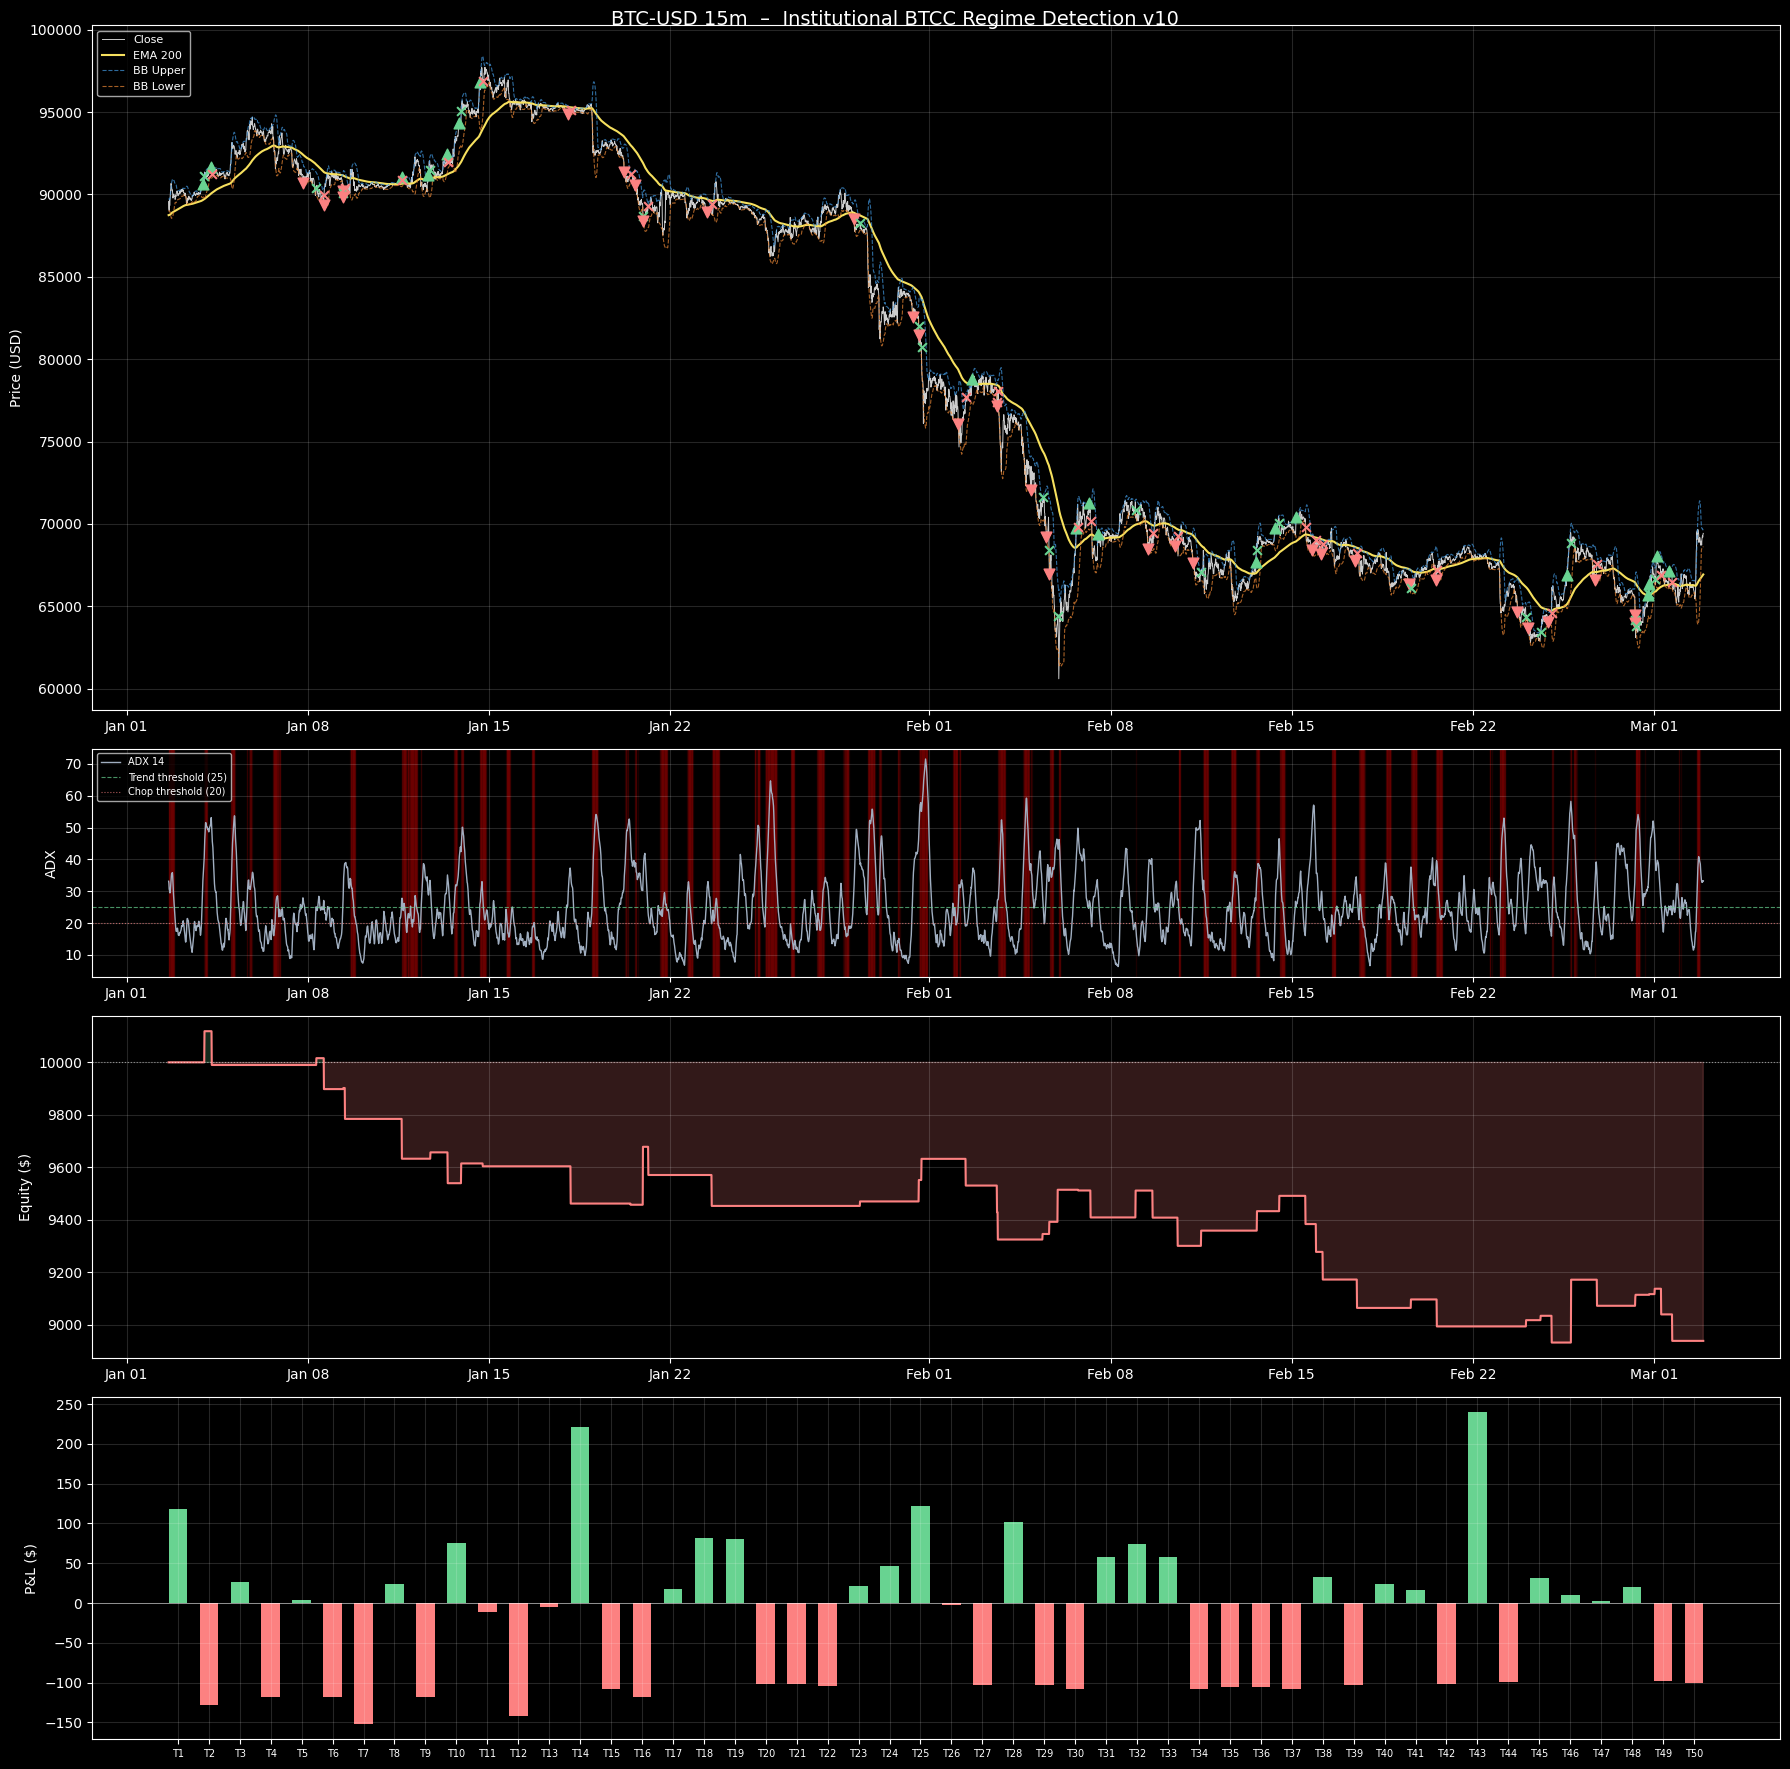

Chart saved → backtest_btcc_regime_results.png


In [19]:
# ── 6. Charts ─────────────────────────────────────────────────────────────────
ec_df = pd.DataFrame(equity_curve).set_index("time")

fig, axes = plt.subplots(4, 1, figsize=(18, 18),
                          gridspec_kw={"height_ratios": [3, 1, 1.5, 1.5]})
fig.suptitle("BTC-USD 30m  –  Institutional BTCC Regime Detection v10", fontsize=14)
plt.style.use("dark_background")

# ── Panel 1: Price + EMA200 + BB + entry/exit signals ────────────────────────
ax1 = axes[0]
ax1.plot(df.index, df["Close"],   color="#cccccc", lw=0.7, label="Close")
ax1.plot(df.index, df["EMA200"],  color="#f6e05e", lw=1.5, label="EMA 200")
ax1.plot(df.index, df["BBUpper"], color="#4299e1", lw=0.8, ls="--", alpha=0.7, label="BB Upper")
ax1.plot(df.index, df["BBLower"], color="#ed8936", lw=0.8, ls="--", alpha=0.7, label="BB Lower")

if not tdf.empty:
    for _, t in tdf.iterrows():
        win_color = "#68d391" if t["dollar_pnl"] >= 0 else "#fc8181"
        mrkr = "^" if t["direction"] == "long" else "v"
        ax1.scatter(t["entry_time"], t["entry"], marker=mrkr,
                    color=("#68d391" if t["direction"] == "long" else "#fc8181"), s=60, zorder=5)
        ax1.scatter(t["exit_time"],  t["exit"],  marker="x", color=win_color, s=40, zorder=5)

ax1.set_ylabel("Price (USD)")
ax1.legend(loc="upper left", fontsize=8)
ax1.grid(alpha=0.15)
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))

# ── Panel 2: ADX + regime shading ────────────────────────────────────────────
ax2 = axes[1]
ax2.plot(df.index, df["ADX"], color="#a0aec0", lw=1.0, label="ADX 14")
ax2.axhline(25, color="#68d391", ls="--", lw=0.8, alpha=0.7, label="Trend threshold (25)")
ax2.axhline(20, color="#fc8181", ls=":",  lw=0.8, alpha=0.7, label="Chop threshold (20)")
# Shade panic volatility bars
panic_bars = df[df["isPanicVolatility"]]
for ts_p in panic_bars.index:
    ax2.axvspan(ts_p, ts_p, alpha=0.1, color="red")
ax2.set_ylabel("ADX")
ax2.legend(loc="upper left", fontsize=7)
ax2.grid(alpha=0.15)
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))

# ── Panel 3: Equity curve ─────────────────────────────────────────────────────
ax3 = axes[2]
final_val    = ec_df["equity"].iloc[-1]
color_line   = "#68d391" if final_val >= INITIAL_CAPITAL else "#fc8181"
ax3.plot(ec_df.index, ec_df["equity"], color=color_line, lw=1.5)
ax3.axhline(INITIAL_CAPITAL, color="white", ls=":", lw=0.8, alpha=0.5)
ax3.fill_between(ec_df.index, INITIAL_CAPITAL, ec_df["equity"],
                 where=ec_df["equity"] >= INITIAL_CAPITAL, alpha=0.2, color="#68d391")
ax3.fill_between(ec_df.index, INITIAL_CAPITAL, ec_df["equity"],
                 where=ec_df["equity"] < INITIAL_CAPITAL,  alpha=0.2, color="#fc8181")
ax3.set_ylabel("Equity ($)")
ax3.grid(alpha=0.15)
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))

# ── Panel 4: Per-trade P&L bars ───────────────────────────────────────────────
ax4 = axes[3]
if not tdf.empty:
    bar_colors = ["#68d391" if v >= 0 else "#fc8181" for v in tdf["dollar_pnl"]]
    ax4.bar(range(len(tdf)), tdf["dollar_pnl"], color=bar_colors, width=0.6)
    ax4.axhline(0, color="white", lw=0.7, alpha=0.5)
    ax4.set_xticks(range(len(tdf)))
    ax4.set_xticklabels([f"T{i+1}" for i in range(len(tdf))], fontsize=7)
ax4.set_ylabel("P&L ($)")
ax4.grid(alpha=0.15)

plt.tight_layout()
plt.savefig("backtest_btcc_regime_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved → backtest_btcc_regime_results.png")

---
## Optimized Strategy – v11

Four targeted fixes to the issues identified in v10 backtests:

| Problem (v10) | Fix (v11) |
|---|---|
| ADX=25 lets weak trends through | **ADX ≥ 30** — require a genuinely strong trend |
| Volume just above SMA accepts thin breakouts | **Volume ≥ 1.5× VolSMA** — demand clear participation |
| MACD cross can be stale / flattening | **MACD histogram must be accelerating** in trade direction |
| Avg loss > avg win (R:R broken) | **Stop = ATR × 1.5 + Hard TP at 2:1 (ATR × 3)** — enforces favorable R:R every trade |

Trailing stop: activates once price moves ATR×1.5 in favor, then trails ATR×1.5 from the best price.

In [8]:
# ── 7. Optimized signals (v11) ────────────────────────────────────────────────
# Stricter filters vs v10
ADX_THRESH   = 30     # was 25 — demand a genuine trend
VOL_MULT     = 1.5    # was 1.0 — demand real participation
BB_CLEARANCE = 0.3    # close must extend ATR×0.3 beyond the BB band

# MACD histogram acceleration (confirms momentum is building, not fading)
df["MACDHist"]    = df["MACD"] - df["MACDSignal"]
df["HistAccelUp"] = (df["MACDHist"] > 0) & (df["MACDHist"] > df["MACDHist"].shift(1))
df["HistAccelDn"] = (df["MACDHist"] < 0) & (df["MACDHist"] < df["MACDHist"].shift(1))

df["OptLongSignal"] = (
    (df["Close"] > df["EMA200"]) &
    (df["MACD"]  > df["MACDSignal"]) &
    (df["Close"] > df["BBUpper"] + df["ATR14"] * BB_CLEARANCE) &
    (df["Volume"] > df["VolSMA"] * VOL_MULT) &
    (df["ADX"] > ADX_THRESH) &
    df["HistAccelUp"] &
    ~df["isPanicVolatility"]
)

df["OptShortSignal"] = (
    (df["Close"] < df["EMA200"]) &
    (df["MACD"]  < df["MACDSignal"]) &
    (df["Close"] < df["BBLower"] - df["ATR14"] * BB_CLEARANCE) &
    (df["Volume"] > df["VolSMA"] * VOL_MULT) &
    (df["ADX"] > ADX_THRESH) &
    df["HistAccelDn"] &
    ~df["isPanicVolatility"]
)

print(f"v11 Long signals : {df['OptLongSignal'].sum()}")
print(f"v11 Short signals: {df['OptShortSignal'].sum()}")

v11 Long signals : 7
v11 Short signals: 26


In [9]:
# ── 8. Optimized backtest simulation (v11) ───────────────────────────────────
# Exit logic: hard TP at 2:1 R:R  +  trailing stop (ATR×1.5 offset)
#   Stop distance = ATR × 1.5   →  max loss per trade = 1 R
#   Hard TP       = ATR × 3.0   →  guaranteed 2 R when hit
#   Trail: activates once price moves ATR×1.5 in favor, then trails ATR×1.5

OPT_STOP_MULT  = 1.5   # stop = ATR × 1.5
OPT_TP_MULT    = 3.0   # TP   = ATR × 3.0  (2:1)
OPT_TRAIL_MULT = 1.5   # trailing offset

opt_equity       = INITIAL_CAPITAL
opt_position     = None
opt_trades       = []
opt_equity_curve = []

for ts, row in df.iterrows():
    close = float(row["Close"])
    high  = float(row["High"])
    low   = float(row["Low"])
    atr   = float(row["ATR14"])
    stop_dist  = atr * OPT_STOP_MULT
    tp_dist    = atr * OPT_TP_MULT
    trail_dist = atr * OPT_TRAIL_MULT

    if opt_position is not None:
        direction = opt_position["direction"]

        if direction == "long":
            if high > opt_position["best_price"]:
                opt_position["best_price"] = high
            # Activate trailing stop once price moves trail_dist in favor
            if opt_position["best_price"] >= opt_position["entry"] + trail_dist:
                trail_sl = opt_position["best_price"] - trail_dist
                opt_position["sl"] = max(opt_position["sl"], trail_sl)
            hit_tp = high  >= opt_position["tp"]
            hit_sl = low   <= opt_position["sl"]
            if hit_tp or hit_sl:
                exit_price = opt_position["tp"] if hit_tp else opt_position["sl"]
                pnl_pct    = (exit_price - opt_position["entry"]) / opt_position["entry"]
        else:
            if low < opt_position["best_price"]:
                opt_position["best_price"] = low
            if opt_position["best_price"] <= opt_position["entry"] - trail_dist:
                trail_sl = opt_position["best_price"] + trail_dist
                opt_position["sl"] = min(opt_position["sl"], trail_sl)
            hit_tp = low   <= opt_position["tp"]
            hit_sl = high  >= opt_position["sl"]
            if hit_tp or hit_sl:
                exit_price = opt_position["tp"] if hit_tp else opt_position["sl"]
                pnl_pct    = (opt_position["entry"] - exit_price) / opt_position["entry"]

        if hit_tp or hit_sl:
            dollar_pnl       = pnl_pct * opt_position["notional"]
            commission       = opt_position["notional"] * COMMISSION_PCT * 2
            dollar_pnl      -= commission
            opt_equity      += dollar_pnl
            opt_trades.append({
                "entry_time" : opt_position["entry_time"],
                "exit_time"  : ts,
                "direction"  : direction,
                "entry"      : opt_position["entry"],
                "exit"       : exit_price,
                "result"     : "TP" if hit_tp else "SL",
                "pnl_pct"    : round(pnl_pct * 100, 3),
                "dollar_pnl" : round(dollar_pnl, 2),
                "equity"     : round(opt_equity, 2),
            })
            opt_position = None

    if opt_position is None:
        if bool(row["OptLongSignal"]):
            risk_capital = opt_equity * RISK_PCT
            qty          = risk_capital / stop_dist
            notional     = qty * close
            opt_position = {
                "direction"  : "long",
                "entry"      : close,
                "entry_time" : ts,
                "sl"         : close - stop_dist,
                "tp"         : close + tp_dist,
                "best_price" : close,
                "notional"   : notional,
            }
        elif bool(row["OptShortSignal"]):
            risk_capital = opt_equity * RISK_PCT
            qty          = risk_capital / stop_dist
            notional     = qty * close
            opt_position = {
                "direction"  : "short",
                "entry"      : close,
                "entry_time" : ts,
                "sl"         : close + stop_dist,
                "tp"         : close - tp_dist,
                "best_price" : close,
                "notional"   : notional,
            }

    opt_equity_curve.append({"time": ts, "equity": opt_equity})

print(f"v11 simulation complete.  Trades found: {len(opt_trades)}")

v11 simulation complete.  Trades found: 25


In [10]:
# ── 9. v11 Summary statistics + side-by-side comparison ─────────────────────
otdf = pd.DataFrame(opt_trades)

def print_stats(tdf_, equity_curve_, label, initial=INITIAL_CAPITAL):
    if tdf_.empty:
        print(f"[{label}] No trades.")
        return
    wins_   = tdf_[tdf_["dollar_pnl"] > 0]
    losses_ = tdf_[tdf_["dollar_pnl"] <= 0]
    wr      = len(wins_) / len(tdf_) * 100
    total   = tdf_["dollar_pnl"].sum()
    final   = tdf_["equity"].iloc[-1]
    gp      = wins_["dollar_pnl"].sum()   if not wins_.empty   else 0
    gl      = losses_["dollar_pnl"].sum() if not losses_.empty else 0
    pf      = gp / abs(gl)                if gl != 0           else float("inf")
    eq_s    = pd.Series([e["equity"] for e in equity_curve_])
    mdd     = ((eq_s - eq_s.cummax()) / eq_s.cummax() * 100).min()
    print(f"{'='*52}")
    print(f"  {label}")
    print(f"{'='*52}")
    print(f"  Return          : {(final/initial - 1)*100:>+9.2f} %")
    print(f"  Net P&L         : ${total:>+10,.2f}")
    print(f"  Max drawdown    : {mdd:>9.2f} %")
    print(f"  Profit factor   : {pf:>9.2f}")
    print(f"  Total trades    : {len(tdf_):>5}")
    print(f"  Win rate        : {wr:>8.1f} %")
    print(f"  Avg win  $      : ${wins_['dollar_pnl'].mean() if not wins_.empty else 0:>+9,.2f}")
    print(f"  Avg loss $      : ${losses_['dollar_pnl'].mean() if not losses_.empty else 0:>+9,.2f}")
    print(f"  Best trade $    : ${tdf_['dollar_pnl'].max():>+9,.2f}")
    print(f"  Worst trade $   : ${tdf_['dollar_pnl'].min():>+9,.2f}")
    print(f"{'='*52}")

print_stats(tdf,   equity_curve,     "v10  BTC-USD 30m 60d  (original)")
print()
print_stats(otdf, opt_equity_curve,  "v11  BTC-USD 30m 60d  (optimized)")
otdf

  v10  BTC-USD 30m 60d  (original)
  Return          :     +0.21 %
  Net P&L         : $    +21.08
  Max drawdown    :     -5.30 %
  Profit factor   :      1.01
  Total trades    :    36
  Win rate        :     55.6 %
  Avg win  $      : $   +85.88
  Avg loss $      : $  -106.03
  Best trade $    : $  +265.74
  Worst trade $   : $  -134.07

  v11  BTC-USD 30m 60d  (optimized)
  Return          :     -2.84 %
  Net P&L         : $   -284.03
  Max drawdown    :     -4.32 %
  Profit factor   :      0.78
  Total trades    :    25
  Win rate        :     44.0 %
  Avg win  $      : $   +93.87
  Avg loss $      : $   -94.04
  Best trade $    : $  +185.82
  Worst trade $   : $  -145.01


,entry_time,exit_time,direction,entry,exit,result,pnl_pct,dollar_pnl,equity
0,2026-01-04 00:30:00+00:00,2026-01-04 01:30:00+00:00,long,91320.898438,91010.493565,SL,-0.340,-135.30,9864.70
1,2026-01-08 06:00:00+00:00,2026-01-08 07:00:00+00:00,short,90185.265625,90076.847765,SL,0.120,0.04,9864.74
2,2026-01-20 05:00:00+00:00,2026-01-20 06:00:00+00:00,short,91645.335938,91316.769023,SL,0.359,50.27,9915.01
3,2026-01-20 06:00:00+00:00,2026-01-20 10:00:00+00:00,short,91141.750000,91078.283244,SL,0.070,-9.59,9905.42
4,2026-01-21 12:00:00+00:00,2026-01-21 13:00:00+00:00,short,88275.179688,88776.067972,SL,-0.567,-120.00,9785.41
5,2026-01-25 08:30:00+00:00,2026-01-25 10:00:00+00:00,short,88188.765625,88408.374938,SL,-0.249,-145.01,9640.41
6,2026-01-29 15:00:00+00:00,2026-01-29 15:30:00+00:00,short,85335.960938,84965.744331,SL,0.434,45.28,9685.69
7,2026-01-29 15:30:00+00:00,2026-01-29 17:00:00+00:00,short,84758.593750,85396.361518,SL,-0.752,-112.30,9573.38
8,2026-01-31 14:00:00+00:00,2026-01-31 14:30:00+00:00,short,81476.742188,81410.390563,SL,0.081,-5.68,9567.70
9,2026-01-31 14:30:00+00:00,2026-01-31 16:30:00+00:00,short,81360.437500,80243.125124,TP,1.373,174.63,9742.34


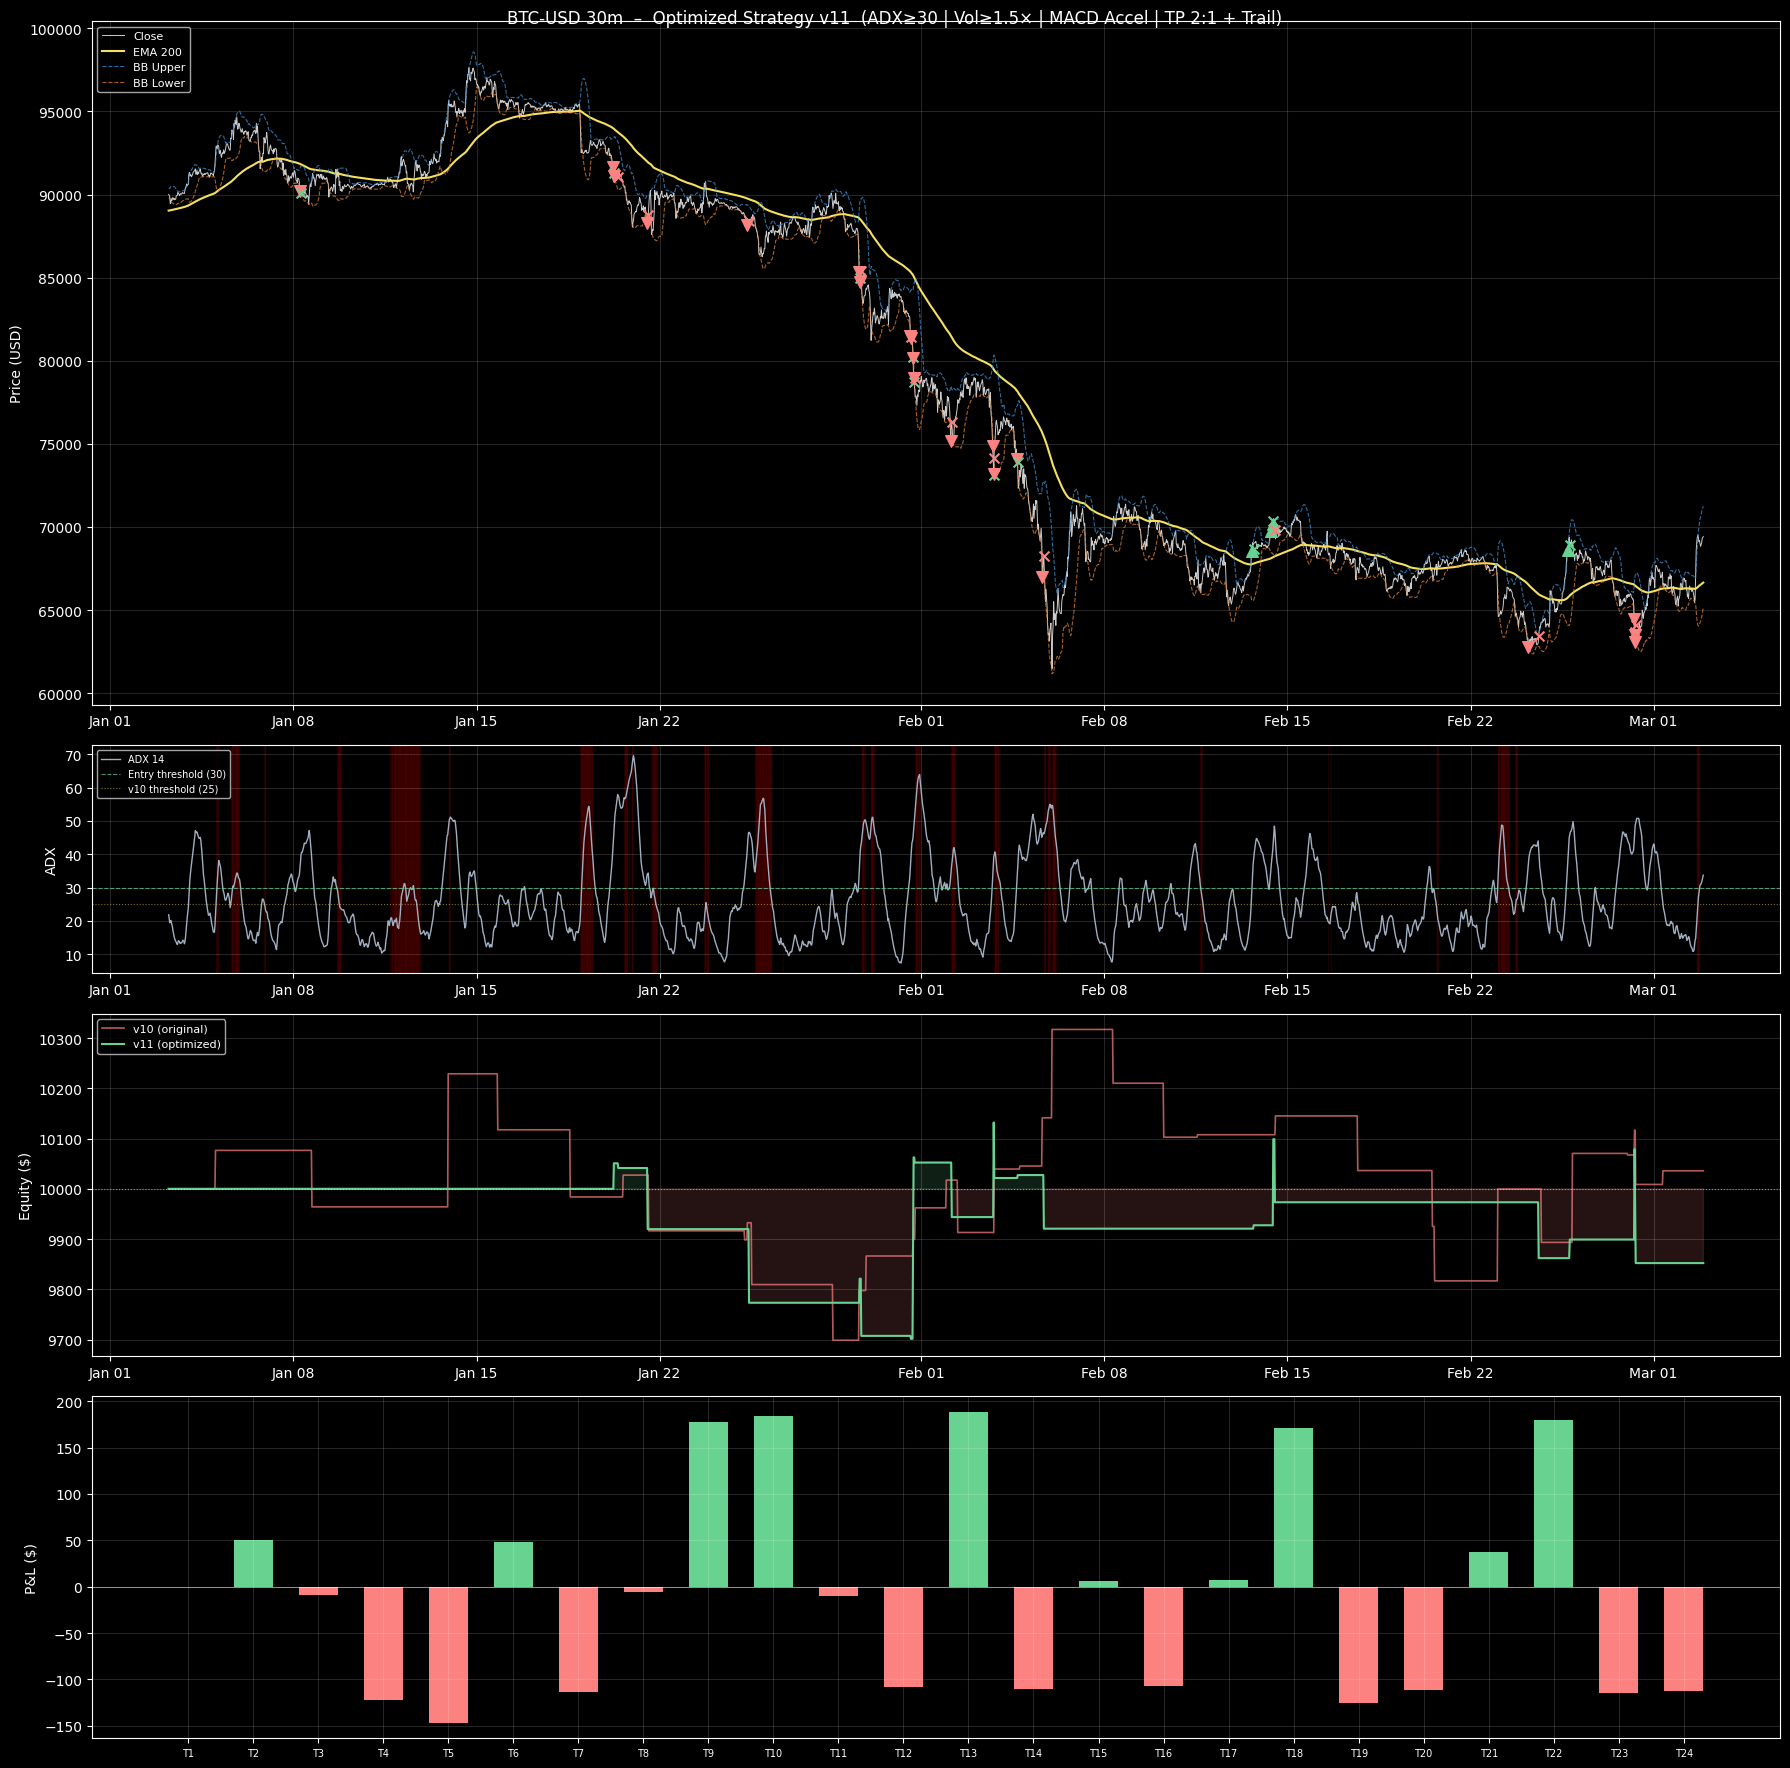

Chart saved → backtest_btcc_v11_optimized.png


In [28]:
# ── 10. v11 Charts ───────────────────────────────────────────────────────────
opt_ec_df = pd.DataFrame(opt_equity_curve).set_index("time")

fig, axes = plt.subplots(4, 1, figsize=(18, 18),
                          gridspec_kw={"height_ratios": [3, 1, 1.5, 1.5]})
fig.suptitle("BTC-USD 30m  –  Optimized Strategy v11  (ADX≥30 | Vol≥1.5× | MACD Accel | TP 2:1 + Trail)", fontsize=12)
plt.style.use("dark_background")

# ── Panel 1: Price + signals ──────────────────────────────────────────────────
ax1 = axes[0]
ax1.plot(df.index, df["Close"],   color="#cccccc", lw=0.7, label="Close")
ax1.plot(df.index, df["EMA200"],  color="#f6e05e", lw=1.5, label="EMA 200")
ax1.plot(df.index, df["BBUpper"], color="#4299e1", lw=0.8, ls="--", alpha=0.7, label="BB Upper")
ax1.plot(df.index, df["BBLower"], color="#ed8936", lw=0.8, ls="--", alpha=0.7, label="BB Lower")
if not otdf.empty:
    for _, t in otdf.iterrows():
        win_col = "#68d391" if t["dollar_pnl"] >= 0 else "#fc8181"
        mrkr    = "^" if t["direction"] == "long" else "v"
        ent_col = "#68d391" if t["direction"] == "long" else "#fc8181"
        ax1.scatter(t["entry_time"], t["entry"], marker=mrkr, color=ent_col, s=70, zorder=5)
        ax1.scatter(t["exit_time"],  t["exit"],  marker="x",  color=win_col,  s=50, zorder=5)
ax1.set_ylabel("Price (USD)")
ax1.legend(loc="upper left", fontsize=8)
ax1.grid(alpha=0.15)
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))

# ── Panel 2: ADX + panic volatility shading ───────────────────────────────────
ax2 = axes[1]
ax2.plot(df.index, df["ADX"], color="#a0aec0", lw=1.0, label="ADX 14")
ax2.axhline(30, color="#68d391", ls="--", lw=0.8, alpha=0.7, label="Entry threshold (30)")
ax2.axhline(25, color="#f6e05e", ls=":",  lw=0.8, alpha=0.5, label="v10 threshold (25)")
for ts_p in df[df["isPanicVolatility"]].index:
    ax2.axvspan(ts_p, ts_p, alpha=0.1, color="red")
ax2.set_ylabel("ADX")
ax2.legend(loc="upper left", fontsize=7)
ax2.grid(alpha=0.15)
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))

# ── Panel 3: Equity curves — v10 vs v11 ──────────────────────────────────────
ax3 = axes[2]
ec_base = pd.DataFrame(equity_curve).set_index("time")
ax3.plot(ec_base.index,   ec_base["equity"],   color="#fc8181", lw=1.2, alpha=0.7, label="v10 (original)")
ax3.plot(opt_ec_df.index, opt_ec_df["equity"], color="#68d391", lw=1.5, label="v11 (optimized)")
ax3.axhline(INITIAL_CAPITAL, color="white", ls=":", lw=0.8, alpha=0.5)
ax3.fill_between(opt_ec_df.index, INITIAL_CAPITAL, opt_ec_df["equity"],
                 where=opt_ec_df["equity"] >= INITIAL_CAPITAL, alpha=0.15, color="#68d391")
ax3.fill_between(opt_ec_df.index, INITIAL_CAPITAL, opt_ec_df["equity"],
                 where=opt_ec_df["equity"] < INITIAL_CAPITAL,  alpha=0.15, color="#fc8181")
ax3.set_ylabel("Equity ($)")
ax3.legend(loc="upper left", fontsize=8)
ax3.grid(alpha=0.15)
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))

# ── Panel 4: Per-trade P&L bars ───────────────────────────────────────────────
ax4 = axes[3]
if not otdf.empty:
    bar_c = ["#68d391" if v >= 0 else "#fc8181" for v in otdf["dollar_pnl"]]
    ax4.bar(range(len(otdf)), otdf["dollar_pnl"], color=bar_c, width=0.6)
    ax4.axhline(0, color="white", lw=0.7, alpha=0.5)
    ax4.set_xticks(range(len(otdf)))
    ax4.set_xticklabels([f"T{i+1}" for i in range(len(otdf))], fontsize=7)
ax4.set_ylabel("P&L ($)")
ax4.grid(alpha=0.15)

plt.tight_layout()
plt.savefig("backtest_btcc_v11_optimized.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved → backtest_btcc_v11_optimized.png")

---
## Strategy v12 — Ground-Up Redesign

### Why the previous strategies underperformed

| Root Cause | Impact |
|---|---|
| **Bollinger Band breakout entry** | Fires *after* the move is mature — entering at extremes that frequently revert. The stop is placed inside a natural reversal zone. |
| **MACD as signal** | Extremely laggy — by the time MACD crosses, the fast EMA has tracked the move for many bars already. |
| **Fixed R:R broken** | A consequence of late entries: the "natural" stop is close to entry (near the BB), but the target is far, so winners are rare and stops get hit frequently. |

### v12 design principles

| Component | v10/v11 | v12 | Reason |
|---|---|---|---|
| Entry signal | BB breakout + MACD | **EMA 9 × EMA 21 crossover** | Fires near the *start* of a trend — dramatically earlier entry, tighter natural stop |
| Mid-term trend | — | **EMA 50 alignment** | EMA9/21 cross must agree with EMA50 direction — eliminates counter-trend fades |
| Macro filter | EMA 200 | EMA 200 ✓ | Keeps only trades aligned with the dominant trend |
| Momentum | MACD histogram | **RSI(14) 40–65 longs / 35–60 shorts** | Avoids chasing overextended moves; confirms healthy momentum |
| Trend strength | ADX > 30 | **ADX > 22** | EMA cross already filters trends; ADX is a secondary guard, not primary |
| Volume | 1.5× SMA20 | **1.2× SMA20** | Slightly relaxed — earlier entries need less volume confirmation |
| Panic volatility | ATR14 > ATR60×1.4 | ATR14 > ATR60×1.4 ✓ | Keeps working well |
| Stop | ATR×1.5 | **ATR×1.5** ✓ | |
| Take profit | ATR×3 hard TP | **ATR×3 hard TP** ✓ | 2:1 R:R enforced |
| Trailing | ATR×1.5 trail | **ATR×1.0 trail** | Tighter trail locks more profit once in the move |

In [11]:
# ── 11. v12 Indicators ───────────────────────────────────────────────────────
# All computed on the existing df (30m, 60d) — no re-download needed.

# EMA stack: 9 / 21 / 50 / 200
df["EMA9"]  = df["Close"].ewm(span=9,   adjust=False).mean()
df["EMA21"] = df["Close"].ewm(span=21,  adjust=False).mean()
df["EMA50"] = df["Close"].ewm(span=50,  adjust=False).mean()
# EMA200 already present from cell 2

# RSI(14)
delta   = df["Close"].diff()
gain    = delta.clip(lower=0)
loss    = (-delta).clip(lower=0)
avg_g   = gain.ewm(alpha=1/14, adjust=False).mean()
avg_l   = loss.ewm(alpha=1/14, adjust=False).mean()
df["RSI"] = 100 - (100 / (1 + avg_g / avg_l.replace(0, 1e-10)))

# EMA9 × EMA21 crossovers
df["CrossUp"]   = (df["EMA9"] > df["EMA21"]) & (df["EMA9"].shift(1) <= df["EMA21"].shift(1))
df["CrossDown"] = (df["EMA9"] < df["EMA21"]) & (df["EMA9"].shift(1) >= df["EMA21"].shift(1))

# Regime flags recomputed (ADX/ATR already in df from earlier cells)
df["isTrendingV12"] = df["ADX"] > 22   # lowered from 30 — EMA cross is primary trend filter

# v12 entry signals
V12_VOL_MULT   = 1.2   # slightly relaxed vs v11
V12_RSI_LO_LNG = 40    # long: momentum must be bullish but not overextended
V12_RSI_HI_LNG = 70
V12_RSI_LO_SHT = 30
V12_RSI_HI_SHT = 60    # short: don't short a deeply oversold bounce

df["V12Long"] = (
    df["CrossUp"] &                               # EMA9 crosses above EMA21
    (df["Close"] > df["EMA200"]) &                # macro bullish
    (df["EMA21"] > df["EMA50"]) &                 # medium-term trend aligned up
    (df["RSI"] >= V12_RSI_LO_LNG) &
    (df["RSI"] <= V12_RSI_HI_LNG) &              # healthy momentum, not overbought
    (df["Volume"] > df["VolSMA"] * V12_VOL_MULT) &
    df["isTrendingV12"] &
    ~df["isPanicVolatility"]
)

df["V12Short"] = (
    df["CrossDown"] &                             # EMA9 crosses below EMA21
    (df["Close"] < df["EMA200"]) &                # macro bearish
    (df["EMA21"] < df["EMA50"]) &                 # medium-term trend aligned down
    (df["RSI"] >= V12_RSI_LO_SHT) &
    (df["RSI"] <= V12_RSI_HI_SHT) &              # healthy momentum, not oversold
    (df["Volume"] > df["VolSMA"] * V12_VOL_MULT) &
    df["isTrendingV12"] &
    ~df["isPanicVolatility"]
)

print(f"v12 Long signals : {df['V12Long'].sum()}")
print(f"v12 Short signals: {df['V12Short'].sum()}")

v12 Long signals : 1
v12 Short signals: 0


In [12]:
# ── 12. v12 Backtest simulation ───────────────────────────────────────────────
# Stop     : ATR × 1.5
# Hard TP  : ATR × 3.0  (2:1 R:R)
# Trailing : activates once price moves ATR×1.5 in favor, then trails ATR×1.0
#            (tighter trail than v11 → locks more profit on big moves)

V12_STOP_MULT  = 1.5
V12_TP_MULT    = 3.0
V12_TRAIL_ACT  = 1.5   # how far price must move before trail starts
V12_TRAIL_DIST = 1.0   # trail distance once active

v12_equity       = INITIAL_CAPITAL
v12_position     = None
v12_trades       = []
v12_equity_curve = []

for ts, row in df.iterrows():
    close = float(row["Close"])
    high  = float(row["High"])
    low   = float(row["Low"])
    atr   = float(row["ATR14"])
    stop_dist  = atr * V12_STOP_MULT
    tp_dist    = atr * V12_TP_MULT
    trail_act  = atr * V12_TRAIL_ACT
    trail_dist = atr * V12_TRAIL_DIST

    # ── Manage open position ──────────────────────────────────────────────────
    hit_tp = hit_sl = False
    exit_price = None

    if v12_position is not None:
        d = v12_position["direction"]

        if d == "long":
            if high > v12_position["best_price"]:
                v12_position["best_price"] = high
            # Enable trail once we're trail_act in profit
            if v12_position["best_price"] >= v12_position["entry"] + trail_act:
                candidate_sl = v12_position["best_price"] - trail_dist
                v12_position["sl"] = max(v12_position["sl"], candidate_sl)
            hit_tp = high  >= v12_position["tp"]
            hit_sl = low   <= v12_position["sl"]
            if hit_tp or hit_sl:
                exit_price = v12_position["tp"] if hit_tp else v12_position["sl"]
                pnl_pct = (exit_price - v12_position["entry"]) / v12_position["entry"]
        else:
            if low < v12_position["best_price"]:
                v12_position["best_price"] = low
            if v12_position["best_price"] <= v12_position["entry"] - trail_act:
                candidate_sl = v12_position["best_price"] + trail_dist
                v12_position["sl"] = min(v12_position["sl"], candidate_sl)
            hit_tp = low   <= v12_position["tp"]
            hit_sl = high  >= v12_position["sl"]
            if hit_tp or hit_sl:
                exit_price = v12_position["tp"] if hit_tp else v12_position["sl"]
                pnl_pct = (v12_position["entry"] - exit_price) / v12_position["entry"]

        if hit_tp or hit_sl:
            dollar_pnl   = pnl_pct * v12_position["notional"]
            commission   = v12_position["notional"] * COMMISSION_PCT * 2
            dollar_pnl  -= commission
            v12_equity  += dollar_pnl
            v12_trades.append({
                "entry_time" : v12_position["entry_time"],
                "exit_time"  : ts,
                "direction"  : d,
                "entry"      : v12_position["entry"],
                "exit"       : exit_price,
                "result"     : "TP" if hit_tp else "SL",
                "pnl_pct"    : round(pnl_pct * 100, 3),
                "dollar_pnl" : round(dollar_pnl, 2),
                "equity"     : round(v12_equity, 2),
            })
            v12_position = None

    # ── New entry ─────────────────────────────────────────────────────────────
    if v12_position is None:
        sig_long  = bool(row["V12Long"])
        sig_short = bool(row["V12Short"])
        if sig_long or sig_short:
            d = "long" if sig_long else "short"
            risk_capital = v12_equity * RISK_PCT
            qty          = risk_capital / stop_dist
            notional     = qty * close
            sl = close - stop_dist if d == "long" else close + stop_dist
            tp = close + tp_dist   if d == "long" else close - tp_dist
            v12_position = {
                "direction"  : d,
                "entry"      : close,
                "entry_time" : ts,
                "sl"         : sl,
                "tp"         : tp,
                "best_price" : close,
                "notional"   : notional,
            }

    v12_equity_curve.append({"time": ts, "equity": v12_equity})

print(f"v12 simulation complete.  Trades found: {len(v12_trades)}")

v12 simulation complete.  Trades found: 1


In [13]:

# ── 13. v12 Summary statistics + three-way comparison ───────────────────────
v12tdf = pd.DataFrame(v12_trades)

print_stats(tdf,    equity_curve,      "v10  BTC-USD 30m 60d  (original)")
print()
print_stats(otdf,   opt_equity_curve,  "v11  BTC-USD 30m 60d  (optimized)")
print()
print_stats(v12tdf, v12_equity_curve,  "v12  BTC-USD 30m 60d  (ground-up redesign)")
v12tdf


  v10  BTC-USD 30m 60d  (original)
  Return          :     +0.21 %
  Net P&L         : $    +21.08
  Max drawdown    :     -5.30 %
  Profit factor   :      1.01
  Total trades    :    36
  Win rate        :     55.6 %
  Avg win  $      : $   +85.88
  Avg loss $      : $  -106.03
  Best trade $    : $  +265.74
  Worst trade $   : $  -134.07

  v11  BTC-USD 30m 60d  (optimized)
  Return          :     -2.84 %
  Net P&L         : $   -284.03
  Max drawdown    :     -4.32 %
  Profit factor   :      0.78
  Total trades    :    25
  Win rate        :     44.0 %
  Avg win  $      : $   +93.87
  Avg loss $      : $   -94.04
  Best trade $    : $  +185.82
  Worst trade $   : $  -145.01

  v12  BTC-USD 30m 60d  (ground-up redesign)
  Return          :     -1.12 %
  Net P&L         : $   -112.07
  Max drawdown    :     -1.12 %
  Profit factor   :      0.00
  Total trades    :     1
  Win rate        :      0.0 %
  Avg win  $      : $    +0.00
  Avg loss $      : $  -112.07
  Best trade $    : $  

,entry_time,exit_time,direction,entry,exit,result,pnl_pct,dollar_pnl,equity
0,2026-02-09 03:30:00+00:00,2026-02-09 06:00:00+00:00,long,71210.289062,70502.142607,SL,-0.994,-112.07,9887.93


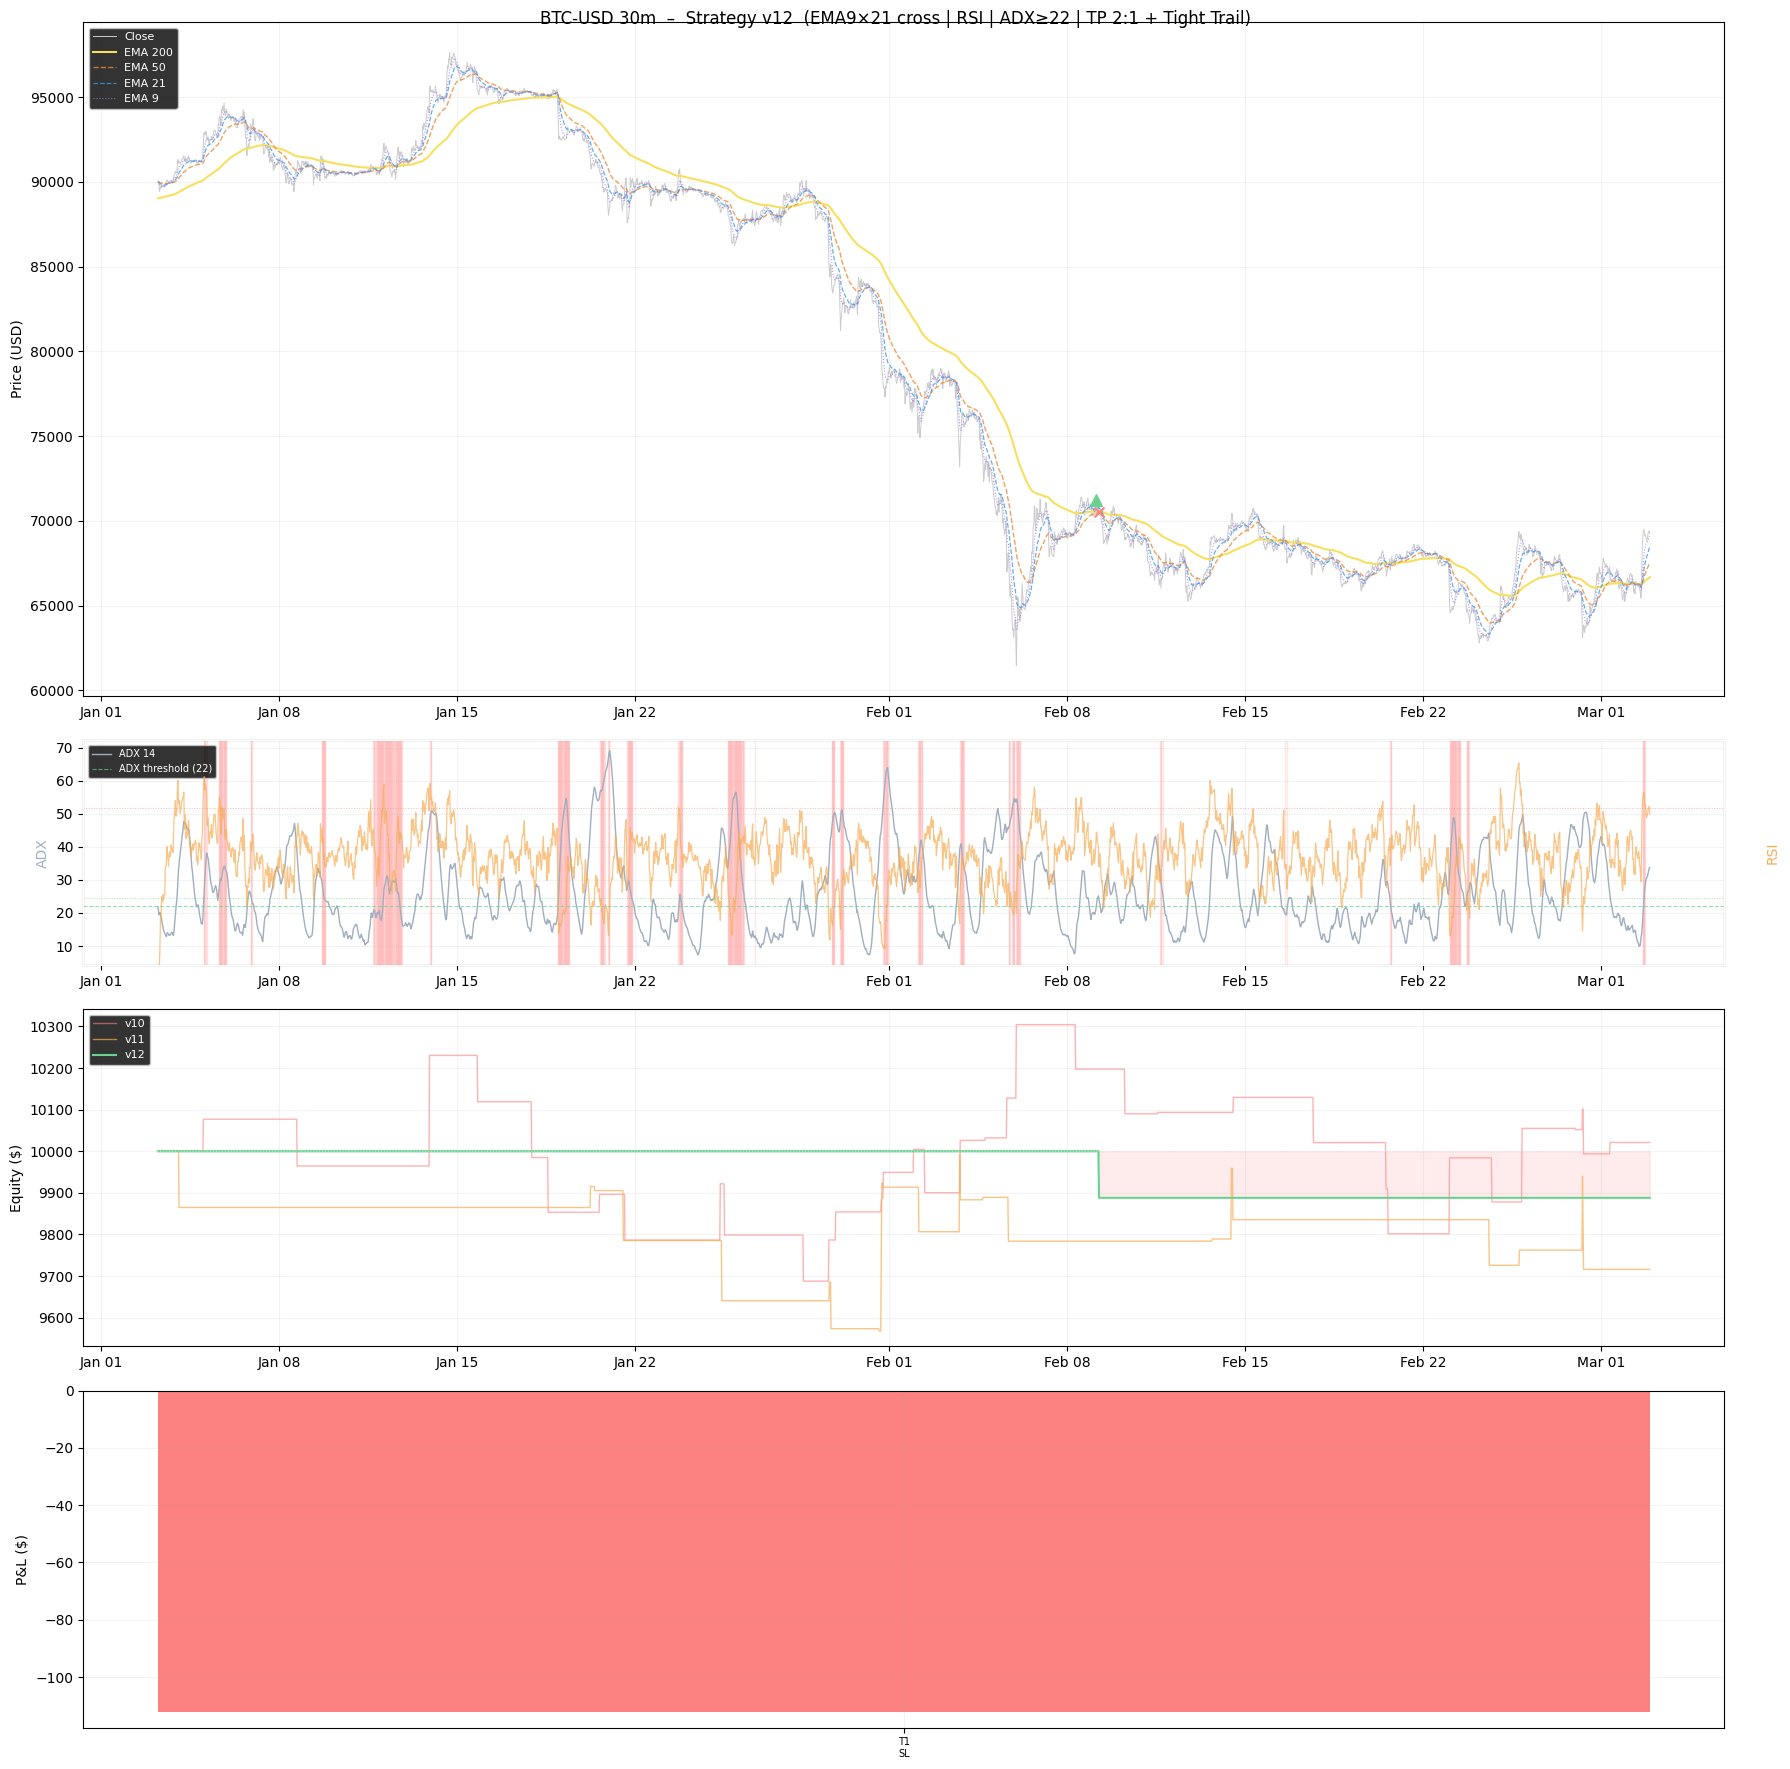

Chart saved → backtest_btcc_v12_redesign.png


In [14]:

# ── 14. v12 Charts ───────────────────────────────────────────────────────────
v12_ec_df = pd.DataFrame(v12_equity_curve).set_index("time")

fig, axes = plt.subplots(4, 1, figsize=(18, 18),
                          gridspec_kw={"height_ratios": [3, 1, 1.5, 1.5]})
fig.suptitle("BTC-USD 30m  –  Strategy v12  (EMA9×21 cross | RSI | ADX≥22 | TP 2:1 + Tight Trail)", fontsize=12)
plt.style.use("dark_background")

# ── Panel 1: Price + EMA stack + entry/exit markers ──────────────────────────
ax1 = axes[0]
ax1.plot(df.index, df["Close"],  color="#cccccc", lw=0.7,  label="Close")
ax1.plot(df.index, df["EMA200"], color="#f6e05e", lw=1.5,  label="EMA 200")
ax1.plot(df.index, df["EMA50"],  color="#ed8936", lw=1.0,  label="EMA 50",  ls="--", alpha=0.8)
ax1.plot(df.index, df["EMA21"],  color="#4299e1", lw=0.9,  label="EMA 21",  ls="--", alpha=0.8)
ax1.plot(df.index, df["EMA9"],   color="#9f7aea", lw=0.8,  label="EMA 9",   ls=":",  alpha=0.8)
if not v12tdf.empty:
    for _, t in v12tdf.iterrows():
        win_col = "#68d391" if t["dollar_pnl"] >= 0 else "#fc8181"
        mrkr    = "^" if t["direction"] == "long" else "v"
        ent_col = "#68d391" if t["direction"] == "long" else "#fc8181"
        ax1.scatter(t["entry_time"], t["entry"], marker=mrkr, color=ent_col, s=70, zorder=5)
        ax1.scatter(t["exit_time"],  t["exit"],  marker="x",  color=win_col,  s=50, zorder=5)
ax1.set_ylabel("Price (USD)")
ax1.legend(loc="upper left", fontsize=8)
ax1.grid(alpha=0.15)
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))

# ── Panel 2: RSI + ADX ───────────────────────────────────────────────────────
ax2 = axes[1]
ax2_rsi = ax2.twinx()
ax2.plot(df.index, df["ADX"], color="#a0aec0", lw=1.0, label="ADX 14")
ax2.axhline(22, color="#68d391", ls="--", lw=0.8, alpha=0.7, label="ADX threshold (22)")
ax2_rsi.plot(df.index, df["RSI"],  color="#f6ad55", lw=0.9, alpha=0.7, label="RSI 14")
ax2_rsi.axhline(70, color="#fc8181", ls=":", lw=0.7, alpha=0.6)
ax2_rsi.axhline(30, color="#68d391", ls=":", lw=0.7, alpha=0.6)
ax2_rsi.set_ylim(0, 100)
for ts_p in df[df["isPanicVolatility"]].index:
    ax2.axvspan(ts_p, ts_p, alpha=0.1, color="red")
ax2.set_ylabel("ADX", color="#a0aec0")
ax2_rsi.set_ylabel("RSI", color="#f6ad55")
ax2.legend(loc="upper left", fontsize=7)
ax2.grid(alpha=0.15)
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))

# ── Panel 3: Equity curves — v10 vs v11 vs v12 ───────────────────────────────
ax3 = axes[2]
ec_base    = pd.DataFrame(equity_curve).set_index("time")
ec_v11     = pd.DataFrame(opt_equity_curve).set_index("time")
ax3.plot(ec_base.index,  ec_base["equity"],   color="#fc8181", lw=1.0, alpha=0.6, label="v10")
ax3.plot(ec_v11.index,   ec_v11["equity"],    color="#f6ad55", lw=1.0, alpha=0.7, label="v11")
ax3.plot(v12_ec_df.index, v12_ec_df["equity"], color="#68d391", lw=1.5,            label="v12")
ax3.axhline(INITIAL_CAPITAL, color="white", ls=":", lw=0.8, alpha=0.5)
ax3.fill_between(v12_ec_df.index, INITIAL_CAPITAL, v12_ec_df["equity"],
                 where=v12_ec_df["equity"] >= INITIAL_CAPITAL, alpha=0.15, color="#68d391")
ax3.fill_between(v12_ec_df.index, INITIAL_CAPITAL, v12_ec_df["equity"],
                 where=v12_ec_df["equity"] < INITIAL_CAPITAL,  alpha=0.15, color="#fc8181")
ax3.set_ylabel("Equity ($)")
ax3.legend(loc="upper left", fontsize=8)
ax3.grid(alpha=0.15)
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))

# ── Panel 4: Per-trade P&L bars ───────────────────────────────────────────────
ax4 = axes[3]
if not v12tdf.empty:
    bar_c = ["#68d391" if v >= 0 else "#fc8181" for v in v12tdf["dollar_pnl"]]
    ax4.bar(range(len(v12tdf)), v12tdf["dollar_pnl"], color=bar_c, width=0.6)
    ax4.axhline(0, color="white", lw=0.7, alpha=0.5)
    ax4.set_xticks(range(len(v12tdf)))
    ax4.set_xticklabels(
        [f"T{i+1}\n{'TP' if r=='TP' else 'SL'}" for i, r in enumerate(v12tdf["result"])],
        fontsize=7)
ax4.set_ylabel("P&L ($)")
ax4.grid(alpha=0.15)

plt.tight_layout()
plt.savefig("backtest_btcc_v12_redesign.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved → backtest_btcc_v12_redesign.png")
